In [ ]:
date1 = "mother_folder"
dl_folder = f"base_path/{date1}_DL"

angle_dl = "single_model_folder"
odd_dl = "odd_model_folder"
somato_dl = "somato_model_folder"

In [ ]:
import os

dl_number = "analysis_dir"
#os.mkdir(f"{dl_folder}/model_{dl_number}")

In [7]:
angle_img  = np.load(f"{dl_folder}/model_{angle_dl}/{date1}_{angle_dl}_allen_image_shap.npy")
odd_img    = np.load(f"{dl_folder}/model_{odd_dl}/{date1}_{odd_dl}_allen_image_shap.npy")
somato_img = np.load(f"{dl_folder}/model_{somato_dl}/{date1}_{somato_dl}_allen_image_shap.npy")

print(angle_img.shape, odd_img.shape, somato_img.shape)

(5, 31, 256, 270) (5, 31, 256, 270) (5, 31, 256, 270)


In [8]:
reshaped_angle = angle_img.reshape(angle_img.shape[0], angle_img.shape[1], angle_img.shape[2]*angle_img.shape[3])
reshaped_odd = odd_img.reshape(odd_img.shape[0], odd_img.shape[1], odd_img.shape[2]*odd_img.shape[3])
reshaped_somato = somato_img.reshape(somato_img.shape[0], somato_img.shape[1], somato_img.shape[2]*somato_img.shape[3])

print(reshaped_angle.shape, reshaped_odd.shape, reshaped_somato.shape)

(5, 31, 69120) (5, 31, 69120) (5, 31, 69120)


In [9]:
nimg_angle, nimg_odd, nimg_somato = np.zeros_like(reshaped_angle), np.zeros_like(reshaped_odd), np.zeros_like(reshaped_somato)
for model in range(nimg_angle.shape[0]):
    nimg_angle[model] = reshaped_angle[model] / np.sum(np.abs(reshaped_angle[model]))
    nimg_odd[model] = reshaped_odd[model] / np.sum(np.abs(reshaped_odd[model]))
    nimg_somato[model] = reshaped_somato[model] / np.sum(np.abs(reshaped_somato[model]))

nimg_angle, nimg_odd, nimg_somato = nimg_angle.transpose(2, 1, 0), nimg_odd.transpose(2, 1, 0), nimg_somato.transpose(2, 1, 0)

print(nimg_angle.shape, nimg_odd.shape, nimg_somato.shape)

(69120, 31, 5) (69120, 31, 5) (69120, 31, 5)


In [10]:
shap_img = np.concatenate((nimg_angle, nimg_odd, nimg_somato), axis=2)
print(shap_img.shape)

(69120, 31, 15)


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

def pca_reduce_axis0_to10(X):
    assert X.ndim == 3 and X.shape[0] >= 10
    C, H, W = X.shape  


    X2 = X.reshape(C, -1).T  # (H*W, C)

    pca = PCA(n_components=10, svd_solver="full", random_state=0)
    Z = pca.fit_transform(X2)  


    Z10 = Z.T.reshape(10, H, W)  

    evr = pca.explained_variance_ratio_ 

    return Z10, evr, pca

In [ ]:
img_10d, img_evr, img_pca = pca_reduce_axis0_to10(shap_img)
print(img_10d.shape)  # -> (10, 31, 15)
print("explained variance ratio:", img_evr)
print("sum explained variance until PC3:", np.sum(img_evr[:3]))
print("sum explained variance:", np.sum(img_evr))

(10, 31, 15)
explained variance ratio: [0.21424146 0.16743292 0.14930706 0.12026057 0.0834079  0.06452535
 0.04414376 0.0371705  0.02313511 0.01967756]
sum explained variance until PC3: 0.5309814486372365
sum explained variance: 0.9233021902348433


In [ ]:
# loadings
loadings_img = img_pca.components_.T * np.sqrt(img_pca.explained_variance_) 

contrib_img = (loadings_img ** 2) / img_pca.explained_variance_ 

print(loadings_img.shape, contrib_img.shape)

(69120, 10) (69120, 10)


In [15]:
loadings_img = loadings_img.reshape(angle_img.shape[2], angle_img.shape[3], 10)
print(loadings_img.shape)

(256, 270, 10)


In [16]:
np.save(f"{dl_folder}/model_{dl_number}/{date1}_{dl_number}_shap_pca_spatial_components.npy", loadings_img)

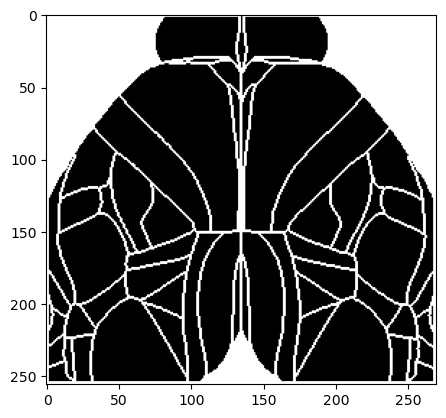

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

atlas_map = np.load("region_border_mask_path")
plt.imshow(atlas_map, cmap='grey')

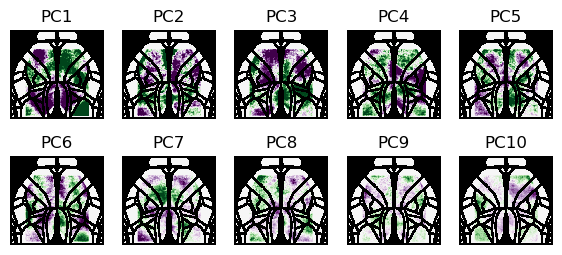

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
for pc in range(loadings_img.shape[2]):
    plt.subplot(2, 5, pc+1)
    mask = atlas_map
    masked = np.ma.masked_where(mask == 1, loadings_img[:, :, pc])
    cmap = plt.cm.PRGn.copy()
    cmap.set_bad(color='black')  
    plt.imshow(masked, cmap=cmap, vmin=-1e-6, vmax=1e-6)
    plt.title(f"PC{pc+1}")
    plt.axis('off')
    #plt.imshow(loadings_img[:, :, pc], cmap='seismic')
    #plt.colorbar()

#plt.show()
#plt.title("Contribution to PC")
#plt.colorbar()
plt.show()

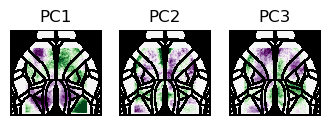

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 2))
for pc in range(3):
    plt.subplot(1, 3, pc+1)
    mask = atlas_map
    masked = np.ma.masked_where(mask == 1, loadings_img[:, :, pc])
    cmap = plt.cm.PRGn.copy()
    cmap.set_bad(color='black') 
    plt.imshow(masked, cmap=cmap, vmin=-2e-6, vmax=2e-6)
    plt.title(f"PC{pc+1}")
    plt.axis('off')
    #plt.imshow(loadings_img[:, :, pc], cmap='seismic')
    #plt.colorbar()

#plt.show()
#plt.title("Contribution to PC")
#plt.colorbar()
plt.show()

In [43]:
angle_3d_i, odd_3d_i, somato_3d_i = img_3d[:, :, 0:5].transpose(2, 1, 0), img_3d[:, :, 5:10].transpose(2, 1, 0), img_3d[:, :, 10:15].transpose(2, 1, 0)
print(angle_3d_i.shape, odd_3d_i.shape, somato_3d_i.shape)

(5, 31, 3) (5, 31, 3) (5, 31, 3)


In [44]:
angle_10d_i, odd_10d_i, somato_10d_i = img_10d[:, :, 0:5].transpose(2, 1, 0), img_10d[:, :, 5:10].transpose(2, 1, 0), img_10d[:, :, 10:15].transpose(2, 1, 0)
print(angle_10d_i.shape, odd_10d_i.shape, somato_10d_i.shape)

(5, 31, 10) (5, 31, 10) (5, 31, 10)


In [47]:
np.save(f"{dl_folder}/model_{dl_number}/{date1}_{dl_number}_shap_pca_temporal_components.npy", img_10d)